In [ ]:
# CELL 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
# CELL 2: Imports and constants
import os, cv2, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

DATA_ROOT     = '/content/avec2014/AVEC2014'
BASELINE_CKPT = '/content/drive/MyDrive/c3d_avec2014_best.pth'
SAVE_DIR      = '/content/drive/MyDrive/avec2014_gradcam'
CLIP_LEN      = 16

os.makedirs(SAVE_DIR, exist_ok=True)

# Unzip dataset
marker = os.path.join(DATA_ROOT, 'labels.csv')
if not os.path.exists(marker):
    print('Extracting dataset...')
    with zipfile.ZipFile('/content/drive/MyDrive/AVEC2014.zip', 'r') as z:
        z.extractall('/content/avec2014')
    print('Done.')
else:
    print('Dataset already extracted.')

print(f'Checkpoint exists: {os.path.exists(BASELINE_CKPT)}')

Device: cpu
Extracting dataset...
Done.
Checkpoint exists: True


In [ ]:
# CELL 3: Selected videos for GradCAM analysis
# Each tuple: (stem, label, comparison_group, note)

SELECTED_VIDEOS = [
    # Glasses comparison
    ('Testing/Freeform/211_2_Freeform_video',  'with_glasses',    'glasses',  'Male, true=3,  covered, glasses detected'),
    ('Testing/Freeform/214_3_Freeform_video',  'no_glasses',      'glasses',  'Male, true=18, covered, no occlusion'),

    # Beard comparison
    ('Testing/Freeform/317_4_Freeform_video',  'with_beard',      'beard',    'Male, true=0,  UNCOVERED, beard detected'),
    ('Testing/Freeform/335_2_Freeform_video',  'no_beard',        'beard',    'Male, true=0,  covered, no occlusion'),

    # Gender comparison
    ('Testing/Freeform/226_2_Freeform_video',  'female',          'gender',   'Female, true=30, covered, no occlusion'),
    ('Testing/Freeform/244_3_Freeform_video',  'male',            'gender',   'Male, true=25, covered, no occlusion'),
]

print('Selected videos:')
for stem, label, group, note in SELECTED_VIDEOS:
    path = os.path.join(DATA_ROOT, stem + '.mp4')
    exists = os.path.exists(path)
    print(f'  [{"OK" if exists else "MISSING"}] {label:15s} {note}')

Selected videos:
  [OK] with_glasses    Male, true=3,  covered, glasses detected
  [OK] no_glasses      Male, true=18, covered, no occlusion
  [OK] with_beard      Male, true=0,  UNCOVERED, beard detected
  [OK] no_beard        Male, true=0,  covered, no occlusion
  [OK] female          Female, true=30, covered, no occlusion
  [OK] male            Male, true=25, covered, no occlusion


In [ ]:
# CELL 4: C3D model definition
# Must match the architecture used during training exactly

class C3D(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.conv1  = nn.Conv3d(3,   64,  kernel_size=(3,3,3), padding=(1,1,1))
        self.pool1  = nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        self.conv2  = nn.Conv3d(64,  128, kernel_size=(3,3,3), padding=(1,1,1))
        self.pool2  = nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2))
        self.conv3a = nn.Conv3d(128, 256, kernel_size=(3,3,3), padding=(1,1,1))
        self.conv3b = nn.Conv3d(256, 256, kernel_size=(3,3,3), padding=(1,1,1))
        self.pool3  = nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2))
        self.conv4a = nn.Conv3d(256, 512, kernel_size=(3,3,3), padding=(1,1,1))
        self.conv4b = nn.Conv3d(512, 512, kernel_size=(3,3,3), padding=(1,1,1))
        self.pool4  = nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2))
        self.conv5a = nn.Conv3d(512, 512, kernel_size=(3,3,3), padding=(1,1,1))
        self.conv5b = nn.Conv3d(512, 512, kernel_size=(3,3,3), padding=(1,1,1))
        self.pool5  = nn.MaxPool3d(kernel_size=(2,2,2), stride=(2,2,2), padding=(0,1,1))
        self.relu    = nn.ReLU(inplace=False)
        self.fc6     = nn.Linear(8192, 4096)
        self.fc7     = nn.Linear(4096, 64)
        self.fc8     = nn.Linear(64, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.relu(self.conv1(x));  x = self.pool1(x)
        x = self.relu(self.conv2(x));  x = self.pool2(x)
        x = self.relu(self.conv3a(x))
        x = self.relu(self.conv3b(x)); x = self.pool3(x)
        x = self.relu(self.conv4a(x))
        x = self.relu(self.conv4b(x)); x = self.pool4(x)
        x = self.relu(self.conv5a(x))
        x = self.relu(self.conv5b(x)); x = self.pool5(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc6(x)))
        x = self.dropout(self.relu(self.fc7(x)))
        return self.fc8(x)

model = C3D().to(device)
model.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
model.eval()
print(f'Model loaded from: {BASELINE_CKPT}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model loaded from: /content/drive/MyDrive/c3d_avec2014_best.pth
Parameters: 61,476,737


In [ ]:
# CELL 5: 3D-GradCAM implementation
# Target layer: conv5b — last conv layer before pooling
# This is standard for C3D GradCAM as it has the highest-level spatial features
# Reference: Selvaraju et al. Grad-CAM, ICCV 2017
#            Tran et al. C3D, ICCV 2015

class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def compute(self, input_tensor):
        """
        input_tensor: (1, 3, T, H, W)
        Returns: cam (T, H, W) — spatiotemporal heatmap
        """
        self.model.zero_grad()
        output = self.model(input_tensor)  # (1, 1)
        output.backward()

        # Global average pool gradients over spatial+temporal dims
        # gradients shape: (1, C, T, H, W)
        weights = self.gradients.mean(dim=(2, 3, 4), keepdim=True)  # (1, C, 1, 1, 1)

        # Weighted combination of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, T, H, W)
        cam = F.relu(cam)  # only positive activations
        cam = cam.squeeze().cpu().numpy()  # (T, H, W)

        # Normalise to 0-1
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam, output.item()

gradcam = GradCAM3D(model, model.conv5b)
print('GradCAM initialised on conv5b layer.')

GradCAM initialised on conv5b layer.


In [ ]:
# CELL 6: Frame extraction and preprocessing

def extract_clip(video_path, n_frames=CLIP_LEN, target_size=112):
    """
    Extract middle n_frames from video.
    Returns:
        tensor: (1, 3, n_frames, H, W) — model input
        raw_frames: list of (H, W, 3) uint8 arrays for visualisation
    """
    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start  = max(0, (total - n_frames) // 2)  # take middle clip

    frames = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    for _ in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (target_size, target_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()

    while len(frames) < n_frames:
        frames.append(frames[-1])

    raw_frames = frames.copy()

    arr = np.stack(frames, axis=0).astype(np.float32) / 255.0
    arr = (arr - MEAN) / STD
    arr = arr.transpose(3, 0, 1, 2)  # (3, T, H, W)
    tensor = torch.from_numpy(arr).unsqueeze(0).to(device)  # (1, 3, T, H, W)
    tensor.requires_grad_(True)

    return tensor, raw_frames


def overlay_cam_on_frame(frame, cam_2d, alpha=0.5):
    """
    Overlay a 2D GradCAM heatmap on a single frame.
    frame: (H, W, 3) uint8
    cam_2d: (H, W) float 0-1
    Returns: (H, W, 3) uint8 overlaid image
    """
    heatmap = cv2.resize(cam_2d, (frame.shape[1], frame.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(frame * (1 - alpha) + heatmap * alpha)
    return overlay


print('Frame extraction and overlay functions defined.')

Frame extraction and overlay functions defined.


In [ ]:
# CELL 7: Run GradCAM on all selected videos

LABEL_MEAN = 15.34
LABEL_STD  = 12.07

results = {}

for stem, label, group, note in SELECTED_VIDEOS:
    path = os.path.join(DATA_ROOT, stem + '.mp4')
    if not os.path.exists(path):
        print(f'MISSING: {path}')
        continue

    print(f'Processing {label} ({note})...')
    tensor, raw_frames = extract_clip(path)

    # Run GradCAM
    cam_3d, raw_pred = gradcam.compute(tensor)
    pred_score = raw_pred * LABEL_STD + LABEL_MEAN

    # cam_3d shape: (T, H_feat, W_feat) — resize to match frame size
    # Average across temporal dimension for a single spatial heatmap
    cam_spatial = cam_3d.mean(axis=0)  # (H_feat, W_feat)

    # Also keep per-frame temporal CAMs
    # Resize each temporal slice to frame size
    T = cam_3d.shape[0]
    cam_per_frame = []
    for t in range(T):
        c = cv2.resize(cam_3d[t], (112, 112))
        cam_per_frame.append(c)

    results[label] = {
        'raw_frames':    raw_frames,
        'cam_spatial':   cam_spatial,
        'cam_per_frame': cam_per_frame,
        'pred_score':    pred_score,
        'group':         group,
        'note':          note
    }
    print(f'  Predicted BDI-II: {pred_score:.1f}')

print(f'\nGradCAM computed for {len(results)} videos.')

Processing with_glasses (Male, true=3,  covered, glasses detected)...
  Predicted BDI-II: 13.1
Processing no_glasses (Male, true=18, covered, no occlusion)...
  Predicted BDI-II: 17.6
Processing with_beard (Male, true=0,  UNCOVERED, beard detected)...
  Predicted BDI-II: 20.5
Processing no_beard (Male, true=0,  covered, no occlusion)...
  Predicted BDI-II: 6.4
Processing female (Female, true=30, covered, no occlusion)...
  Predicted BDI-II: 15.2
Processing male (Male, true=25, covered, no occlusion)...
  Predicted BDI-II: 22.3

GradCAM computed for 6 videos.


Available temporal frames: 2, using indices: [0, 0, 0, 1]


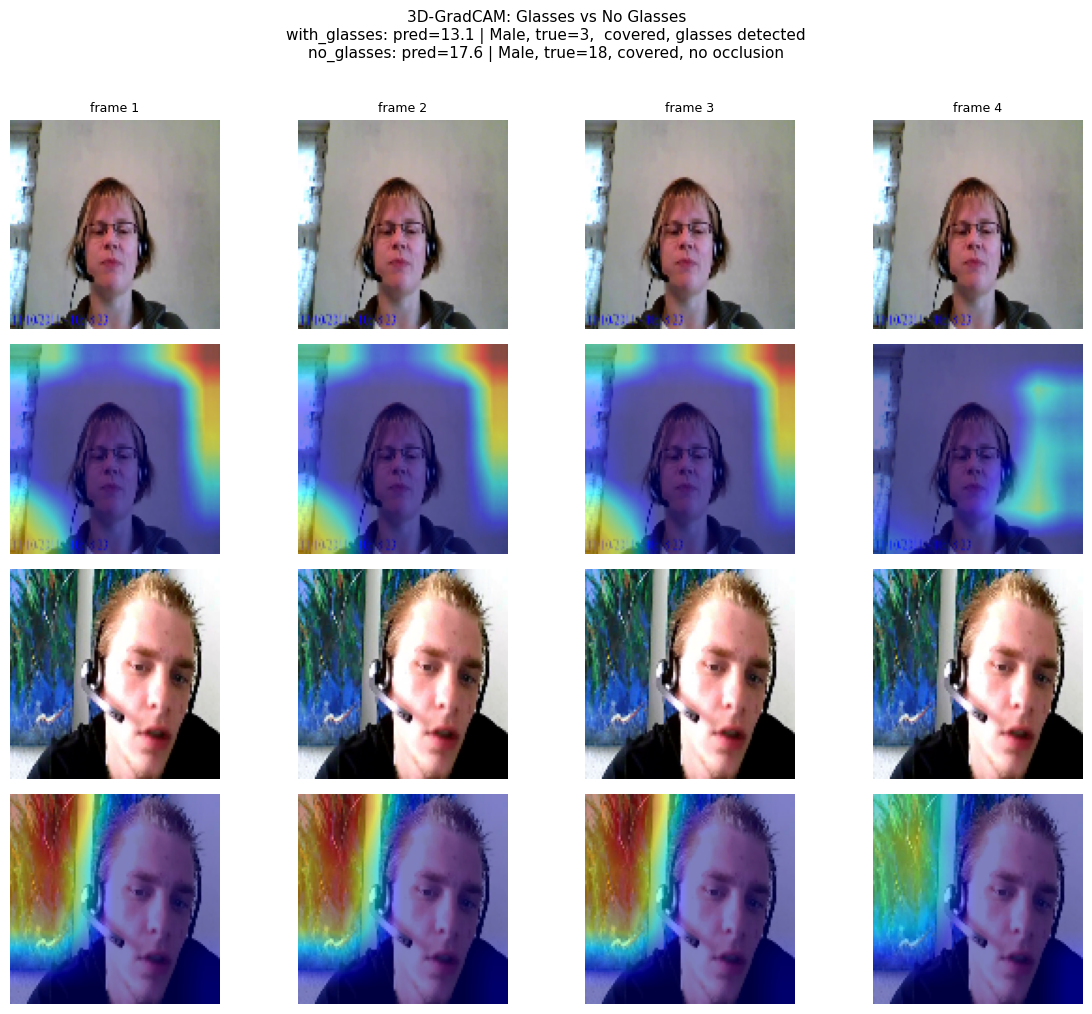

Saved: /content/drive/MyDrive/avec2014_gradcam/gradcam_glasses_comparison.png


In [ ]:
# CELL 8: Figure — Glasses comparison
def plot_comparison(label_a, label_b, title, filename):
    res_a = results[label_a]
    res_b = results[label_b]

    # Auto-detect available frames and pick 4 evenly spaced
    n_avail = min(len(res_a['cam_per_frame']), len(res_b['cam_per_frame']))
    frame_indices = [int(i) for i in np.linspace(0, n_avail-1, 4)]
    print(f'Available temporal frames: {n_avail}, using indices: {frame_indices}')

    n_frames = len(frame_indices)
    fig, axes = plt.subplots(4, n_frames, figsize=(n_frames * 3, 10))

    row_labels = [
        f'{label_a.replace("_", " ").title()}\nraw frame',
        f'{label_a.replace("_", " ").title()}\nGradCAM',
        f'{label_b.replace("_", " ").title()}\nraw frame',
        f'{label_b.replace("_", " ").title()}\nGradCAM',
    ]

    for col, fi in enumerate(frame_indices):
        frame_a   = res_a['raw_frames'][fi]
        cam_a     = res_a['cam_per_frame'][fi]
        overlay_a = overlay_cam_on_frame(frame_a, cam_a)

        frame_b   = res_b['raw_frames'][fi]
        cam_b     = res_b['cam_per_frame'][fi]
        overlay_b = overlay_cam_on_frame(frame_b, cam_b)

        for row, img in enumerate([frame_a, overlay_a, frame_b, overlay_b]):
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(row_labels[row], fontsize=9,
                                          rotation=0, ha='right', va='center',
                                          labelpad=80)
        axes[0][col].set_title(f'frame {col+1}', fontsize=9)

    pred_a = res_a['pred_score']
    pred_b = res_b['pred_score']
    note_a = res_a['note']
    note_b = res_b['note']

    fig.suptitle(
        f'{title}\n'
        f'{label_a}: pred={pred_a:.1f} | {note_a}\n'
        f'{label_b}: pred={pred_b:.1f} | {note_b}',
        fontsize=11, y=1.01
    )

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, filename)
    plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {path}')


plot_comparison(
    'with_glasses', 'no_glasses',
    '3D-GradCAM: Glasses vs No Glasses',
    'gradcam_glasses_comparison.png'
)

Available temporal frames: 2, using indices: [0, 0, 0, 1]


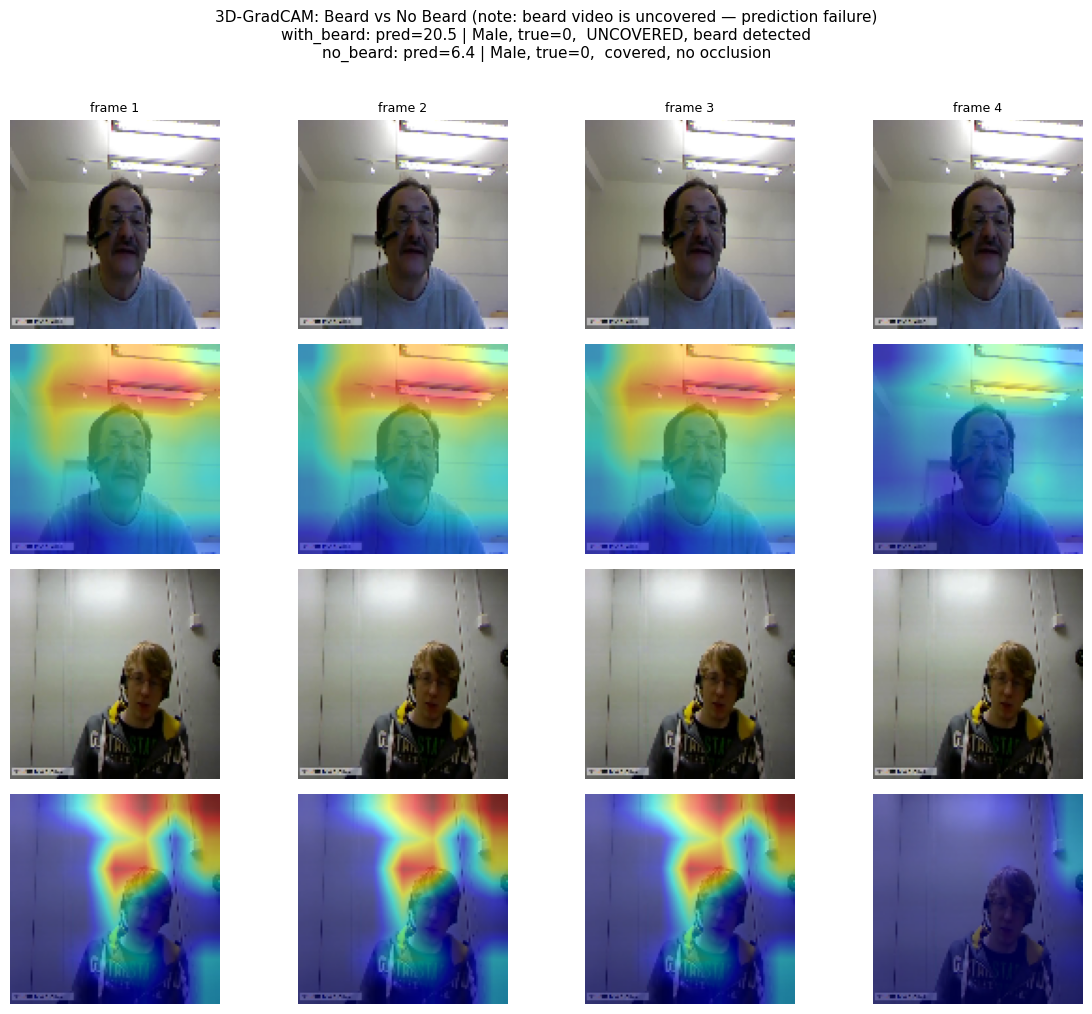

Saved: /content/drive/MyDrive/avec2014_gradcam/gradcam_beard_comparison.png


In [ ]:
# CELL 9: Figure — Beard comparison
plot_comparison(
    'with_beard', 'no_beard',
    '3D-GradCAM: Beard vs No Beard (note: beard video is uncovered — prediction failure)',
    'gradcam_beard_comparison.png'
)

Available temporal frames: 2, using indices: [0, 0, 0, 1]


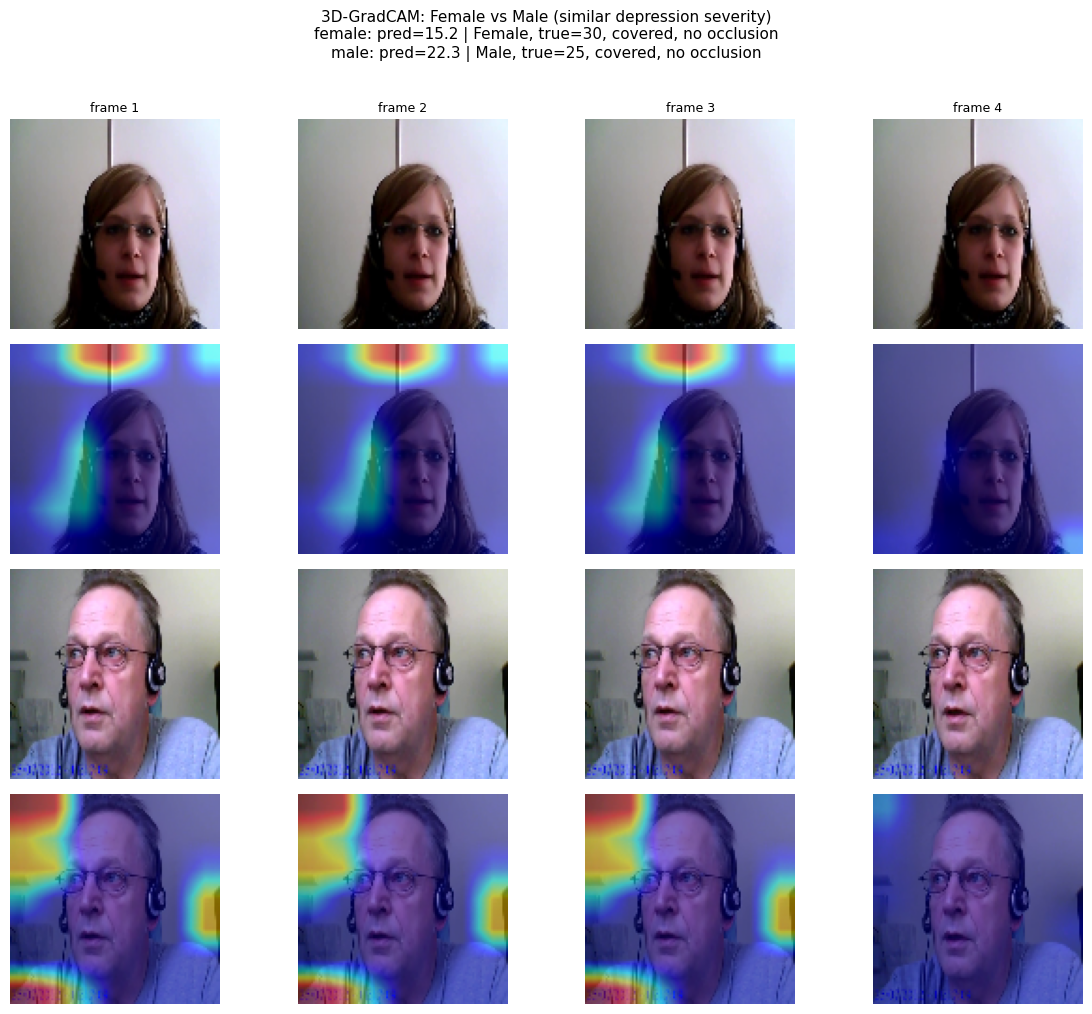

Saved: /content/drive/MyDrive/avec2014_gradcam/gradcam_gender_comparison.png


In [ ]:
# CELL 10: Figure — Gender comparison
plot_comparison(
    'female', 'male',
    '3D-GradCAM: Female vs Male (similar depression severity)',
    'gradcam_gender_comparison.png'
)

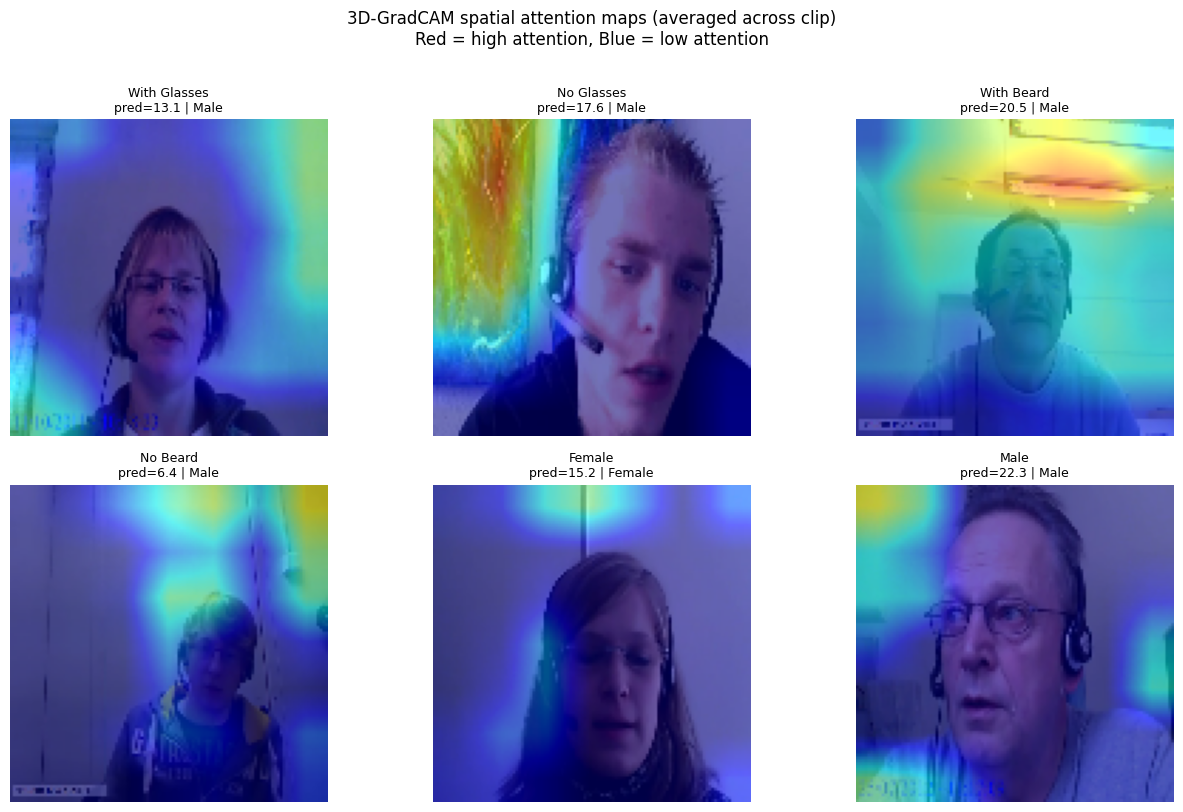

Saved: /content/drive/MyDrive/avec2014_gradcam/gradcam_all_attention_maps.png


In [ ]:
# CELL 11: Figure — Spatial attention heatmaps (averaged across all frames)
# Shows where model attends overall per video as a single image

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

labels_ordered = [
    ('with_glasses', 'With Glasses'),
    ('no_glasses',   'No Glasses'),
    ('with_beard',   'With Beard'),
    ('no_beard',     'No Beard'),
    ('female',       'Female'),
    ('male',         'Male'),
]

for ax, (label, title) in zip(axes.flatten(), labels_ordered):
    if label not in results:
        ax.axis('off')
        continue
    res = results[label]

    # Middle frame as background
    mid_frame = res['raw_frames'][8]
    cam_avg   = res['cam_spatial']

    overlay = overlay_cam_on_frame(mid_frame, cam_avg, alpha=0.55)
    ax.imshow(overlay)
    ax.axis('off')

    pred  = res['pred_score']
    note  = res['note'].split(',')[0]  # first part only
    ax.set_title(f'{title}\npred={pred:.1f} | {note}', fontsize=9)

plt.suptitle('3D-GradCAM spatial attention maps (averaged across clip)\nRed = high attention, Blue = low attention',
             fontsize=12, y=1.01)
plt.tight_layout()
path = os.path.join(SAVE_DIR, 'gradcam_all_attention_maps.png')
plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {path}')

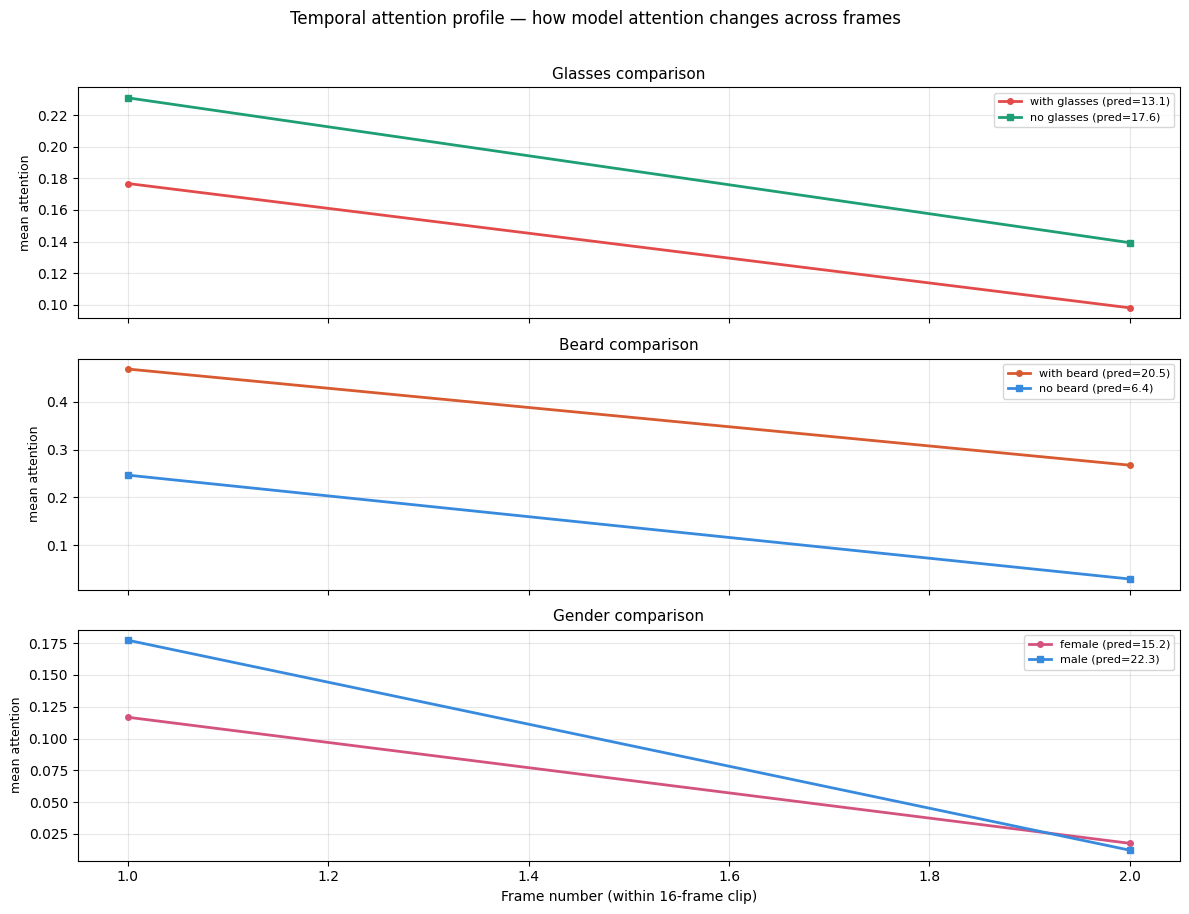

Saved: /content/drive/MyDrive/avec2014_gradcam/gradcam_temporal_attention.png


In [ ]:
# CELL 12: Figure — Temporal attention profile
# Shows how attention changes over time within each clip
# Useful for showing whether model attends more to certain moments

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

comparison_pairs = [
    ('with_glasses', 'no_glasses',   'Glasses comparison',   '#E24B4A', '#1D9E75'),
    ('with_beard',   'no_beard',     'Beard comparison',     '#D85A30', '#378ADD'),
    ('female',       'male',         'Gender comparison',    '#D4537E', '#378ADD'),
]

for ax, (la, lb, title, ca, cb) in zip(axes, comparison_pairs):
    if la not in results or lb not in results:
        continue

    # Mean attention per frame
    attn_a = [cam.mean() for cam in results[la]['cam_per_frame']]
    attn_b = [cam.mean() for cam in results[lb]['cam_per_frame']]

    frames = range(1, len(attn_a)+1)
    ax.plot(frames, attn_a, color=ca, linewidth=2,
            label=f'{la.replace("_"," ")} (pred={results[la]["pred_score"]:.1f})', marker='o', markersize=4)
    ax.plot(frames, attn_b, color=cb, linewidth=2,
            label=f'{lb.replace("_"," ")} (pred={results[lb]["pred_score"]:.1f})', marker='s', markersize=4)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('mean attention', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame number (within 16-frame clip)', fontsize=10)
plt.suptitle('Temporal attention profile — how model attention changes across frames',
             fontsize=12, y=1.01)
plt.tight_layout()
path = os.path.join(SAVE_DIR, 'gradcam_temporal_attention.png')
plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {path}')

Face region attention analysis:
Video                  Upper face   Lower face
----------------------------------------------
With Glasses                1.070        0.930
No Glasses                  1.398        0.602
With Beard                  1.309        0.691
No Beard                    1.552        0.448
Female                      1.140        0.860
Male                        1.230        0.770


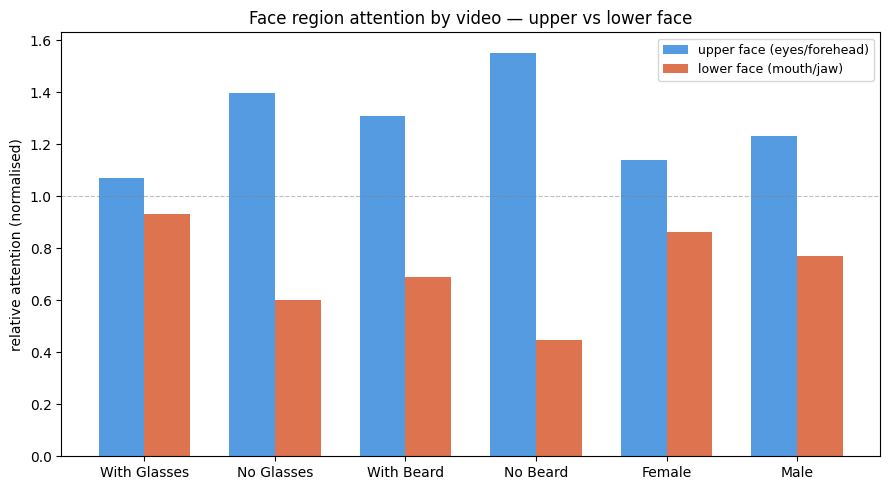

Saved: /content/drive/MyDrive/avec2014_gradcam/gradcam_face_region_attention.png


In [ ]:
# CELL 13: Face region attention analysis
# Divide face into regions and quantify where model attends
# Regions: upper face (eyes/forehead), lower face (mouth/jaw), background

def face_region_attention(cam_per_frame, h=112, w=112):
    """
    Split averaged CAM into face regions and compute mean attention.
    Upper face: top 50% of image (eyes, forehead)
    Lower face: bottom 50% of image (mouth, jaw, beard area)
    """
    cam_avg = np.mean([cv2.resize(c, (w, h)) for c in cam_per_frame], axis=0)
    upper   = cam_avg[:h//2, :].mean()
    lower   = cam_avg[h//2:, :].mean()
    total   = cam_avg.mean()
    return upper/total, lower/total

print('Face region attention analysis:')
print(f'{"Video":20s} {"Upper face":>12s} {"Lower face":>12s}')
print('-' * 46)
for label, title in labels_ordered:
    if label not in results:
        continue
    upper, lower = face_region_attention(results[label]['cam_per_frame'])
    print(f'{title:20s} {upper:>12.3f} {lower:>12.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
labels_plot  = []
upper_vals   = []
lower_vals   = []

for label, title in labels_ordered:
    if label not in results:
        continue
    upper, lower = face_region_attention(results[label]['cam_per_frame'])
    labels_plot.append(title)
    upper_vals.append(upper)
    lower_vals.append(lower)

x = np.arange(len(labels_plot))
w = 0.35
ax.bar(x - w/2, upper_vals, w, label='upper face (eyes/forehead)', color='#378ADD', alpha=0.85)
ax.bar(x + w/2, lower_vals, w, label='lower face (mouth/jaw)',     color='#D85A30', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylabel('relative attention (normalised)', fontsize=10)
ax.set_title('Face region attention by video — upper vs lower face', fontsize=12)
ax.legend(fontsize=9)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
path = os.path.join(SAVE_DIR, 'gradcam_face_region_attention.png')
plt.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {path}')

In [ ]:
# CELL 14: Summary of all saved GradCAM figures
print('=== GradCAM figures saved to Drive ===')
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith('.png'):
        size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e3
        print(f'  {f}  ({size:.0f} KB)')

print('\n=== Prediction summary ===')
for stem, label, group, note in SELECTED_VIDEOS:
    if label in results:
        pred = results[label]['pred_score']
        true_score = note.split('true=')[1].split(',')[0]
        print(f'  {label:20s} true={true_score:>4s}  pred={pred:.1f}')

=== GradCAM figures saved to Drive ===
  gradcam_all_attention_maps.png  (288 KB)
  gradcam_beard_comparison.png  (324 KB)
  gradcam_face_region_attention.png  (71 KB)
  gradcam_gender_comparison.png  (336 KB)
  gradcam_glasses_comparison.png  (320 KB)
  gradcam_temporal_attention.png  (268 KB)

=== Prediction summary ===
  with_glasses         true=   3  pred=13.1
  no_glasses           true=  18  pred=17.6
  with_beard           true=   0  pred=20.5
  no_beard             true=   0  pred=6.4
  female               true=  30  pred=15.2
  male                 true=  25  pred=22.3
